# Consensus under self-symmetric resolution-9 rules on small-world networks

**Question.** Which Life-like rules $\phi^9_{\beta,\sigma}$ that are symmetric under state complementation drive a small-world network to *consensus* (all nodes in the same state), how fast, and how do they compare with the stochastic threshold rule (Watts' majority with a fair coin at $\rho = 1/2$)?

**Setup.**

| | |
|---|---|
| rules | the 256 self-symmetric rules of resolution $r = 9$ that keep $\rho = 0$ at $\rho = 0$, plus Watts' majority rule |
| networks | 100 Watts–Strogatz networks: $N = 1000$, ring with $k = 8$ neighbours, rewiring $p = 0.05$ |
| initial states | exactly 500 living nodes; one configuration per network, shared by every rule |
| measured | first timestep $t_c$ at which all nodes agree, up to $T_\text{max} = 10^5$ (also reported at $10^4$); for a run without consensus, a cycle that proves it never gets there, if one is found |

That is 25,700 runs, about 3 minutes on an Apple M4. Run with the `fast-llna` environment after `pip install -e ".[notebook]"`.

For resolutions 5 to 10 across the rewiring probability $p$, see `consensus_sweep.ipynb`.

In [1]:
import time

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from IPython.display import Markdown, display
from scipy.stats import binomtest

import fast_llna as fl

R_RES = 9  # resolution r of the density partition
N_NODES = 1000  # nodes per network
K, P = 8, 0.05  # Watts-Strogatz: ring with K neighbours per node, rewiring probability P
SAMPLES = 100  # (network, initial configuration) pairs, shared by all rules
T_MAX = 100_000  # runs without consensus by T_MAX are censored
T_EARLY = 10_000  # earlier horizon, also reported
SEED_INIT, SEED_MAJORITY = 1, 2  # network s is generated with seed s

print("backends available:", fl.available_backends())

backends available: ['metal', 'cpu', 'reference']


## 1. The self-symmetric rules

Resolution $r$ splits the density interval $[0, 1]$ into $r$ cells $R_0, \dots, R_{r-1}$, mirrored around $\rho = 1/2$. For odd $r$ the central cell is closed; for $r = 9$ it is $R_4 = [4/9, 5/9]$. A node with density $\rho$ in cell $R_j$ is born if bit $j$ of $\beta$ is set (dead node) or survives if bit $j$ of $\sigma$ is set (living node).

Complementing every state turns rule $\phi^r_{\beta,\sigma}$ into an equivalent rule $\phi^r_{\beta',\sigma'}$ (thesis, App. symmetry):
$$\beta' = 2^r - 1 - \overline{\sigma}, \qquad \sigma' = 2^r - 1 - \overline{\beta},$$
where $\overline{v}$ reverses the $r$ bits of $v$, i.e. maps cell $R_j$ to $R_{r-1-j}$ (mirroring $\rho \mapsto 1 - \rho$).

A rule is **self-symmetric** (self-equivalent) when $(\beta', \sigma') = (\beta, \sigma)$: its global map commutes with complementation, $\Phi(\neg x) = \neg\Phi(x)$.

**Counting them.**
- Bit reversal is an involution, so $\beta = 2^r - 1 - \overline{\sigma}$ holds exactly when $\sigma = 2^r - 1 - \overline{\beta}$. The two conditions are one.
- So $\beta$ is free and fixes $\sigma$:
$$\boxed{\sigma = 2^r - 1 - \overline{\beta}} \qquad\Longrightarrow\qquad 2^r = 512 \text{ self-symmetric rules out of } 4^r = 262\,144.$$
- In words: a living node survives at density $\rho$ exactly when a dead node at density $1 - \rho$ would *not* be born.
- Consistency check: the $2^{2r-1} + 2^{r-1}$ classes of `fl.nonequivalent` are the $(4^r - 2^r)/2$ equivalent pairs plus these $2^r$ singletons.

The cell below takes them from `fl.self_equivalent` and checks that `fl.equivalent` maps each one to itself and that it satisfies the closed form.

In [2]:
FULL = 2**R_RES - 1


def mirror(v):
    """Reverse the R_RES bits of v: cell j <-> cell R_RES - 1 - j."""
    return int(f"{v:0{R_RES}b}"[::-1], 2)


codes = fl.self_equivalent(R_RES)  # int64 [2^r, 2]: (beta, sigma), sorted by beta
assert len(codes) == 2**R_RES
assert np.array_equal(np.stack(fl.equivalent(R_RES, *codes.T), axis=1), codes)  # each is its own equivalent
assert all(s == FULL - mirror(b) for b, s in codes)
print(f"{len(codes)} self-symmetric rules out of {4**R_RES:,}")

512 self-symmetric rules out of 262,144


**Keeping $\rho = 0$ at $\rho = 0$.** We keep only rules in which a dead node with no living neighbours stays dead: $\beta_0 = 0$.
- For a self-symmetric rule, bit $r - 1$ of $\sigma$ is $1 - \beta_0$. A kept rule therefore also keeps $\rho = 1$ at $\rho = 1$: both uniform states are fixed points, and consensus, once reached, stays put.
- The dropped half ($\beta_0 = 1$) turns all-dead into all-alive and back, forever.
- Dropping them loses no information. Each dropped rule is the output complement $(2^r-1-\beta,\ 2^r-1-\sigma)$ of a kept one, and for self-symmetric $\Phi$ we have $\neg\Phi(\neg\Phi(x)) = \Phi(\Phi(x))$. Its trajectory is therefore the kept rule's with every odd timestep complemented, and it reaches the uniform states at exactly the same timesteps.

That leaves $2^{r-1} = 256$ rules.

In [3]:
kept = codes[codes[:, 0] % 2 == 0]  # beta_0 = 0: rho = 0 stays rho = 0
dropped = codes[codes[:, 0] % 2 == 1]
assert np.array_equal(codes[:, 1] >> (R_RES - 1), 1 - codes[:, 0] % 2)  # sigma_8 = 1 - beta_0
assert {tuple(c) for c in FULL - dropped} == {tuple(c) for c in kept}  # the dropped are output complements of the kept
beta, sigma = kept.T
rules = fl.life_like(R_RES, beta, sigma)
print(f"{len(rules)} rules keep rho = 0 at rho = 0; the first few (beta, sigma):",
      ", ".join(f"({b}, {s})" for b, s in zip(beta[:5], sigma[:5], strict=True)))

256 rules keep rho = 0 at rho = 0; the first few (beta, sigma): (0, 511), (2, 383), (4, 447), (6, 319), (8, 479)


## 2. The threshold rule

Watts' majority rule ignores the node's own state:
- alive if $\rho > 1/2$;
- dead if $\rho < 1/2$;
- a fair coin at $\rho = 1/2$ exactly, which needs an even in-degree.

It is not a $\phi^9$ rule: its tie is a single point, not a cell. So it runs on its own three-cell partition `fl.MAJORITY`, in a separate `fl.consensus` call. It is self-symmetric in distribution.

Its closest deterministic relative among the 256 is $\phi^9_{480,496}$, with $B = \{R_5, \dots, R_8\}$ and $S = \{R_4, \dots, R_8\}$:
- it follows the strict majority outside the central cell;
- it *keeps its state* inside $R_4 = [4/9, 5/9]$;
- at degree 8 the only density in $R_4$ is exactly $1/2$, so there it is majority with "keep on tie" instead of a coin.

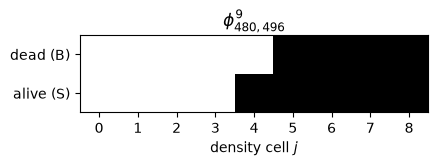

In [4]:
def show_rule(ax, b, s):
    """Response diagram: next state (black = alive) per density cell, for dead (B) and living (S) nodes."""
    cells = np.arange(R_RES)
    ax.imshow([(b >> cells) & 1, (s >> cells) & 1], cmap="Greys", vmin=0, vmax=1)
    ax.set(xticks=cells, yticks=[0, 1], yticklabels=["dead (B)", "alive (S)"], xlabel="density cell $j$")
    ax.set_title(rf"$\phi^{{{R_RES}}}_{{{b},{s}}}$")


assert FULL - mirror(480) == 496
fig, ax = plt.subplots(figsize=(4.5, 1.6))
show_rule(ax, 480, 496)
plt.show()

## 3. Networks and initial states

**Networks.** Each network is `networkx.connected_watts_strogatz_graph(1000, 8, 0.05, seed=s)`:
- a ring in which every node links to its 4 nearest neighbours on either side;
- every edge rewired with probability 0.05, retried until the network is connected;
- every node keeps the 4 edges it "owns", so degrees start at 4.

**One graph for all networks.** `fl.union` joins the 100 networks into one graph of 100,000 nodes with a block-diagonal adjacency, so there are no edges between networks and one `simulate` call evolves all 100 at once. Network $s$ occupies nodes $1000s, \dots, 1000s + 999$, and node index equals ring position. The `offsets` that `fl.union` returns mark these blocks, so that `fl.consensus` can check each network on its own.

**Initial states.** `fl.random_states` gives one configuration per network with exactly 500 living nodes. Every rule, and the majority rule, starts from the same 100 configurations. This paired design means differences between rules are not differences in luck.

union: 100,000 nodes, 800,000 directed edges; degree 4..12, mean 8.00; 72% of nodes have even degree (majority ties possible)


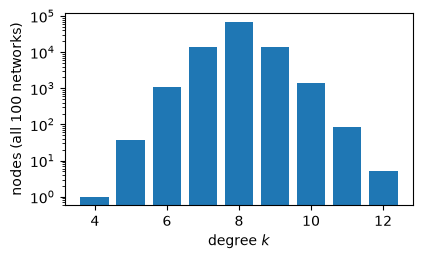

In [5]:
nets = [
    fl.Graph(nx.to_scipy_sparse_array(nx.connected_watts_strogatz_graph(N_NODES, K, P, seed=s)))
    for s in range(SAMPLES)
]
graph, offsets = fl.union(*nets)  # network s is nodes offsets[s] .. offsets[s + 1] - 1
x0 = fl.random_states(N_NODES, SAMPLES, seed=SEED_INIT).to_bool()  # [SAMPLES, N_NODES], 500 alive each

deg = graph.degree
print(f"union: {graph.n:,} nodes, {len(graph.indices):,} directed edges; degree {deg.min()}..{deg.max()}, "
      f"mean {deg.mean():.2f}; {np.mean(deg % 2 == 0):.0%} of nodes have even degree (majority ties possible)")
fig, ax = plt.subplots(figsize=(4.5, 2.5))
ax.bar(*np.unique(deg, return_counts=True))
ax.set(xlabel="degree $k$", ylabel="nodes (all 100 networks)", yscale="log")
plt.show()

## 4. Consensus: definition and detection

**Definition.** A network is in consensus at timestep $t$ when all 1000 nodes share one state. The consensus time is $t_c = \min\{t : x^t \text{ uniform}\}$.

**Consensus is absorbing for every rule here.** In a uniform network every node is in the same state and sees $\rho = 0$ (all dead) or $\rho = 1$ (all alive), so all nodes do the same thing. A uniform network stays uniform, possibly blinking. Hence $t_c$ is well defined and "consensus by $t$" only ever switches on.

**Never, for certain.** A deterministic rule on a finite network is a finite deterministic system. Once a configuration repeats without consensus ($x^{t} = x^{t - \lambda}$, not uniform), the run is in a cycle and can never reach consensus: it would have to be in the cycle already.

**Detection.** `fl.consensus` follows every run up to $T_\text{max}$ and records both:
- **Consensus.** All 256 rules run as bit-lanes of one simulation, and network $s$ is a block of 1000 consecutive node rows. A bitwise AND over a block has bit $i$ set iff all its nodes are alive under rule $i$; a bitwise OR has bit $i$ clear iff all are dead. So every timestep is checked without unpacking the lanes.
- **Cycles** (deterministic rules only). Each run keeps a reference configuration, replaced at every power of two ($t = 1, 2, 4, \dots$), and every frame is compared with it. The first return to the reference gives the exact minimal period $\lambda$. This finds every cycle whose transient $\mu$ and period $\lambda$ are both at most some power of two $2^j$ with $2^j + \lambda \le T_\text{max}$. At $T_\text{max} = 10^5$ that is every cycle entered by $t = 65\,536$ with a period of at most $34\,464$; a cycle entered after $t = 65\,536$, or with a longer period, is not found.

A run with neither consensus nor a cycle found by $T_\text{max}$ is **open**: it has not entered a cycle by $t = 65\,536$, or it is in one with a period above $34\,464$. Majority is stochastic, so it has no cycles: its runs reach consensus or stay open.

## 5. Simulation

Recording every timestep of 25,600 runs for $10^5$ steps would need 320 GB. `fl.consensus` therefore advances in chunks of at most 32 steps:
- each chunk is one `simulate` call that continues from the last frame of the previous one with `t0 = t`;
- continuation is exact, because randomness depends only on (seed, timestep, node, replica), so the chunk size does not change any result;
- the call returns once every run has reached consensus or shown a cycle, or at $T_\text{max}$.

In [6]:
start = time.perf_counter()
c = fl.consensus(graph, rules, x0.ravel(), T_MAX, offsets=offsets)  # [SAMPLES, rules]; same start for every rule
print(f"{len(rules)} rules x {SAMPLES} networks to t = {T_MAX:,}: {time.perf_counter() - start:.0f} s")

start = time.perf_counter()
c_maj = fl.consensus(graph, fl.majority(0.5), x0.ravel(), T_MAX, offsets=offsets, seed=SEED_MAJORITY)
t_maj = c_maj.t_consensus[:, 0]
print(f"majority x {SAMPLES} networks to t = {T_MAX:,}: {time.perf_counter() - start:.0f} s")

256 rules x 100 networks to t = 100,000: 158 s


majority x 100 networks to t = 100,000: 12 s


## 6. Results

### Overview

Each rule falls into exactly one class:
- **always**: all 100 runs reach consensus;
- **sometimes**: some runs reach consensus;
- **never: every run cycles**: every run entered a cycle (of any period) without consensus, which proves that none of these 100 runs ever reaches consensus;
- **never within $T_\text{max}$: some runs open**: no run reached consensus, and some are open at $T_\text{max}$.

In [7]:
reached, cycled = np.isfinite(c.t_consensus), np.isfinite(c.t_cycle)  # [sample, rule]
n_hit, n_cyc = reached.sum(0), cycled.sum(0)
n_open = SAMPLES - n_hit - n_cyc  # neither consensus nor a cycle by T_MAX
classes = {
    "always consensus": n_hit == SAMPLES,
    "sometimes consensus": (n_hit > 0) & (n_hit < SAMPLES),
    "never: every run cycles": n_cyc == SAMPLES,
    "never within T_MAX: some runs open": (n_hit == 0) & (n_open > 0),
}
for name, member in classes.items():
    print(f"{member.sum():4d} rules  {name}")
print(f"\nruns: {reached.sum():,} consensus, {cycled.sum():,} cycle without consensus, "
      f"{n_open.sum():,} open at T_MAX (of {reached.size:,})")
period, t_ref = c.period[cycled], (c.t_cycle - c.period)[cycled]  # the cycle was entered by t_ref
print(f"cycle periods: 1 (frozen) in {np.mean(period == 1):.1%} of cycling runs, 2 in {np.mean(period == 2):.1%}; "
      f"median {np.median(period):.0f}, max {period.max():,}")
late = 2 ** np.arange(12, 17)  # references at t = 4,096 .. 65,536
print("cycles by the reference that found them: " + ", ".join(f"{np.sum(t_ref == t):,} at t = {t:,}" for t in late)
      + f"; {np.sum(t_ref < late[0]):,} before")
print(f"runs in consensus by t = {T_EARLY:,}: {(c.t_consensus <= T_EARLY).sum():,}")
print(f"majority: {np.isfinite(t_maj).sum()} of {SAMPLES} runs reach consensus ({(t_maj <= T_EARLY).sum()} by {T_EARLY:,})")
i = int(np.searchsorted(beta, 480))
print(f"phi_{beta[i]},{sigma[i]}: {n_cyc[i]} of {SAMPLES} runs cycle; period "
      + ", ".join(f"{v} in {n}" for v, n in zip(*np.unique(c.period[cycled[:, i], i], return_counts=True), strict=True))
      + f" runs; every cycle entered by t = {(c.t_cycle - c.period)[cycled[:, i], i].max():,.0f}")

   0 rules  always consensus
   2 rules  sometimes consensus
 118 rules  never: every run cycles
 136 rules  never within T_MAX: some runs open

runs: 21 consensus, 12,367 cycle without consensus, 13,212 open at T_MAX (of 25,600)
cycle periods: 1 (frozen) in 17.6% of cycling runs, 2 in 32.4%; median 3, max 16,380
cycles by the reference that found them: 54 at t = 4,096, 72 at t = 8,192, 89 at t = 16,384, 63 at t = 32,768, 62 at t = 65,536; 12,027 before
runs in consensus by t = 10,000: 10
majority: 0 of 100 runs reach consensus (0 by 10,000)
phi_480,496: 100 of 100 runs cycle; period 1 in 83, 2 in 17 runs; every cycle entered by t = 16


### Rules that reach consensus

Columns:
- **runs by $10^4$ / $10^5$**: how many of the 100 networks reach consensus by each horizon.
- **cycle / open**: of the other networks, how many end in a cycle (so never reach consensus) and how many are open at $T_\text{max}$.
- **$t_c$ where reached**: min / median / max over the runs that do reach consensus by $T_\text{max}$.
- **vs majority**: on the same network and initial state, how often the rule is faster (wins) or slower (losses); a run without consensus by $T_\text{max}$ counts as $t_c = \infty$. The $p$-value is a two-sided sign test on wins against losses.

In [8]:
def row(name, t, t_cycle, versus_majority=True):
    done, n_cyc = t[np.isfinite(t)], int(np.isfinite(t_cycle).sum())
    span = " / ".join(f"{v:.0f}" for v in (done.min(), np.median(done), done.max())) if done.size else "-"
    cells = [name, str((done <= T_EARLY).sum()), str(done.size), f"{n_cyc} / {SAMPLES - done.size - n_cyc}", span, "", ""]
    if versus_majority:
        wins, losses = int((t < t_maj).sum()), int((t > t_maj).sum())
        cells[5] = f"{wins} / {losses}"
        cells[6] = f"{binomtest(wins, wins + losses).pvalue:.2g}" if wins + losses else "-"
    return "| " + " | ".join(cells) + " |"


lead = list(np.flatnonzero(n_hit))
lead.sort(key=lambda i: (-n_hit[i], np.median(c.t_consensus[:, i])))
lines = ["| rule | runs by $10^4$ | runs by $10^5$ | cycle / open | $t_c$ where reached | vs majority: wins / losses "
         "| sign test $p$ |", "|---|---|---|---|---|---|---|"]
lines += [row(rf"$\phi^9_{{{beta[i]},{sigma[i]}}}$", c.t_consensus[:, i], c.t_cycle[:, i]) for i in lead]
lines.append(row("Watts majority, coin at $\\rho = 1/2$", t_maj, c_maj.t_cycle[:, 0], versus_majority=False))
display(Markdown("\n".join(lines)))

| rule | runs by $10^4$ | runs by $10^5$ | cycle / open | $t_c$ where reached | vs majority: wins / losses | sign test $p$ |
|---|---|---|---|---|---|---|
| $\phi^9_{408,460}$ | 1 | 12 | 21 / 67 | 4075 / 20348 / 87912 | 12 / 0 | 0.00049 |
| $\phi^9_{424,468}$ | 9 | 9 | 91 / 0 | 159 / 239 / 390 | 9 / 0 | 0.0039 |
| Watts majority, coin at $\rho = 1/2$ | 0 | 0 | 0 / 100 | - |  |  |

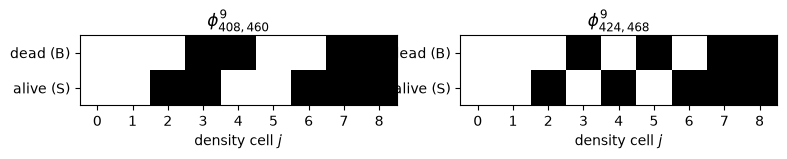

In [9]:
if lead:
    fig, axes = plt.subplots(1, len(lead), figsize=(4.5 * len(lead), 1.6), squeeze=False)
    for ax, i in zip(axes[0], lead, strict=True):
        show_rule(ax, beta[i], sigma[i])
    plt.show()

### Time to consensus

Each curve is the fraction of the 100 runs that are in consensus by timestep $t$, i.e. one minus the survival curve. Its height at $T_\text{max}$ is the fraction that reached consensus at all. The dotted line marks $10^4$.

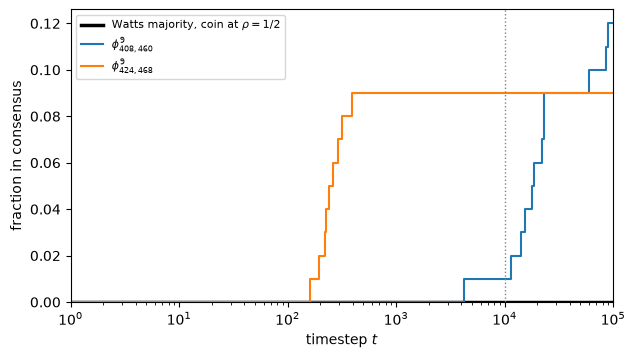

In [10]:
t_grid = np.unique(np.geomspace(1, T_MAX, 400).astype(int))


def reached_by(t):
    return (t[:, None] <= t_grid).mean(axis=0)


fig, ax = plt.subplots(figsize=(7, 3.8))
ax.step(t_grid, reached_by(t_maj), where="post", color="k", lw=2.5, label=r"Watts majority, coin at $\rho = 1/2$")
for i in lead:
    ax.step(t_grid, reached_by(c.t_consensus[:, i]), where="post", label=rf"$\phi^9_{{{beta[i]},{sigma[i]}}}$")
ax.axvline(T_EARLY, color="grey", ls=":", lw=1)
ax.set(xscale="log", xlim=(1, T_MAX), ylim=(0, None), xlabel="timestep $t$", ylabel="fraction in consensus")
ax.legend(loc="upper left", fontsize=8)
plt.show()

### What the runs look like

The space-time diagrams below show the first network that the most successful rule (the first row of the table) brings to consensus. Nodes run left to right in ring order, time runs downward, and black means alive. Each rule starts from the same initial configuration.

The majority run is the same one as above: same seed and same node indices in the union graph.

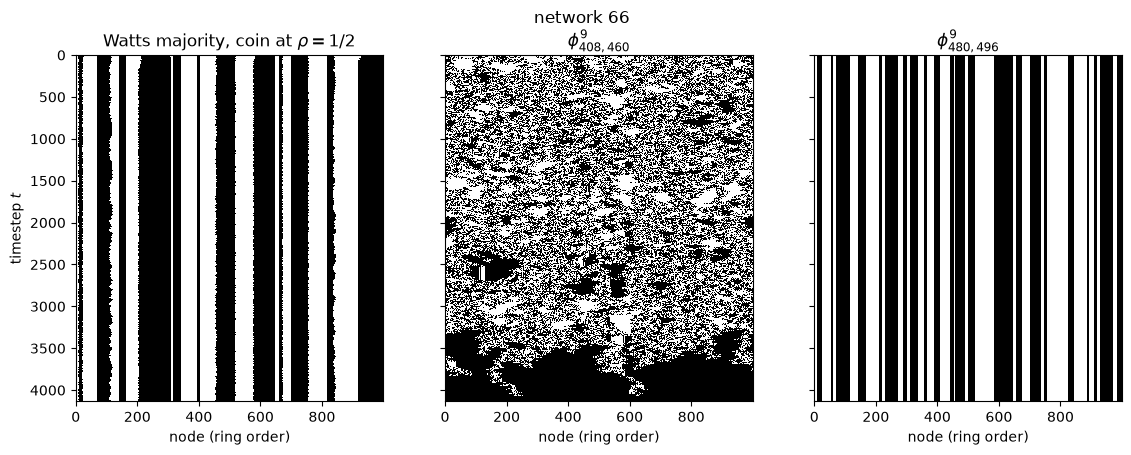

In [11]:
if lead:
    s = int(np.argmin(c.t_consensus[:, lead[0]]))
    shown = [lead[0], int(np.searchsorted(beta, 480))]
    t_show = int(min(10_000, c.t_consensus[s, lead[0]] + 60))
else:
    s, shown, t_show = 0, [int(np.searchsorted(beta, 480))], 300

# majority: the union run of section 5 (same seed, same node indices), cut to network s (one bit per node)
maj = fl.simulate(graph, fl.majority(0.5), x0.reshape(1, -1), t_show, seed=SEED_MAJORITY).states.bits
cut = slice(s * N_NODES // 8, (s + 1) * N_NODES // 8)  # needs N_NODES % 8 == 0
panels = [(r"Watts majority, coin at $\rho = 1/2$", fl.States(maj[:, cut], 1, N_NODES).to_bool()[:, 0])]
# deterministic rules: network s on its own evolves exactly as inside the union
det = fl.simulate(nets[s], rules.take(shown), np.broadcast_to(x0[s], (len(shown), N_NODES)), t_show)
panels += [(rf"$\phi^9_{{{beta[i]},{sigma[i]}}}$", x)
           for i, x in zip(shown, det.states.to_bool().swapaxes(0, 1), strict=True)]

fig, axes = plt.subplots(1, len(panels), figsize=(4.5 * len(panels), 4.5), sharey=True)
for ax, (title, x) in zip(axes, panels, strict=True):
    ax.imshow(x, cmap="Greys", aspect="auto", interpolation="nearest")
    ax.set(title=title, xlabel="node (ring order)")
axes[0].set_ylabel("timestep $t$")
fig.suptitle(f"network {s}")
plt.show()

## 7. Conclusions

These hold for the default parameters: $k = 8$, $p = 0.05$, $\rho^0 = 1/2$ exactly, $T_\text{max} = 10^5$. Change them in the first code cell and re-run (about 3 minutes).

**Consensus is rare at $r = 9$.** Only 2 of the 256 rules ever reach it:
- $\phi^9_{408,460}$: 12 of 100 networks, slowly. Only 1 by $10^4$; the median $t_c$ is about 20,000, and the curve is still rising at $10^5$. Of the other 88 networks, 21 end in a cycle and 67 are open.
- $\phi^9_{424,468}$: 9 of 100 networks, quickly (159 to 390 steps). The other 91 all end in a cycle, so on those it provably never does.

**The rest.**
- 118 rules provably never reach consensus here: every run entered a cycle without it.
- 136 rules have runs that are open at $10^5$ (13,212 runs in total).
- Most cycles are short: of the 12,367 runs that cycle, 17.6% end in a fixed point and 32.4% in a 2-cycle, and the median period is 3. The longest period found is 16,380.
- Cycles were still being found late: 62 only with the last reference, at $t = 65\,536$. With $T_\text{max} = 65\,536$ they would have counted as open, so the open count depends on the horizon.

**Watts' majority rule reaches consensus in none of the 100 runs, not even by $10^5$.**
- Within a few tens of steps it freezes into domains. Afterwards only nodes along the domain walls keep flipping, and the walls barely move.
- Its deterministic relative $\phi^9_{480,496}$ provably never reaches consensus here: every run ends in a fixed point (83 runs) or a 2-cycle (17 runs), entered by $t = 16$.

**Paired comparison.** Both rules are faster than majority on every network where they reach consensus and slower on none (sign test $p = 0.0005$ and $p = 0.004$).

See `consensus_r8.ipynb` for resolution 8, whose cell edge at $\rho = 1/2$ does better.

**Caveats.**
- "Provably never" holds for these 100 networks and initial states only.
- Cycle detection is exact but bounded: at $T_\text{max} = 10^5$ a cycle entered after $t = 65\,536$, or with a period above $34\,464$, is not found. An open run may be in such a cycle, or may still reach consensus after $T_\text{max}$.
- $\rho^0 = 1/2$ exactly leaves no initial majority to amplify, which is the hardest case for consensus.
- The results depend strongly on the rewiring probability $p$. In quick runs outside these notebooks (same seeds), Watts' majority reached consensus within $10^4$ steps in 1 of 100 runs at $p = 0.2$ and in all 100 at $p = 1$. `consensus_sweep.ipynb` follows this across $p$.
- Majority has one coin realisation per network.